# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [17]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)

Reading the shape and columns of the dataframe provides information on all the data.

In [18]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data cleaning & Data preprocessing)**

### **Data Cleaning**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [19]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

No missing values found in dataset


For further data cleaning, we are detecting outliers to remove biasness and reduce error during data mining. The features 'RANGE', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3' are chosen for outlier detection as these features are important to training the distance estimation model. <br>

By removing outliers in 'RANGE', we remove unusually high or low values that can possibly mean that the measurement process went wrong or error in the data entry. <br>

By removing outliers in 'FP_AMP1', 'FP_AMP2', and 'FP_AMP3', we remove amplitude values that are also unusually high or low due to errors like sensor malfunction, or noise. <br>

To detect these outliers, we are using boxplots, Z-score, and interquartile range to better visualize the data and decide the appropriate data to clean.

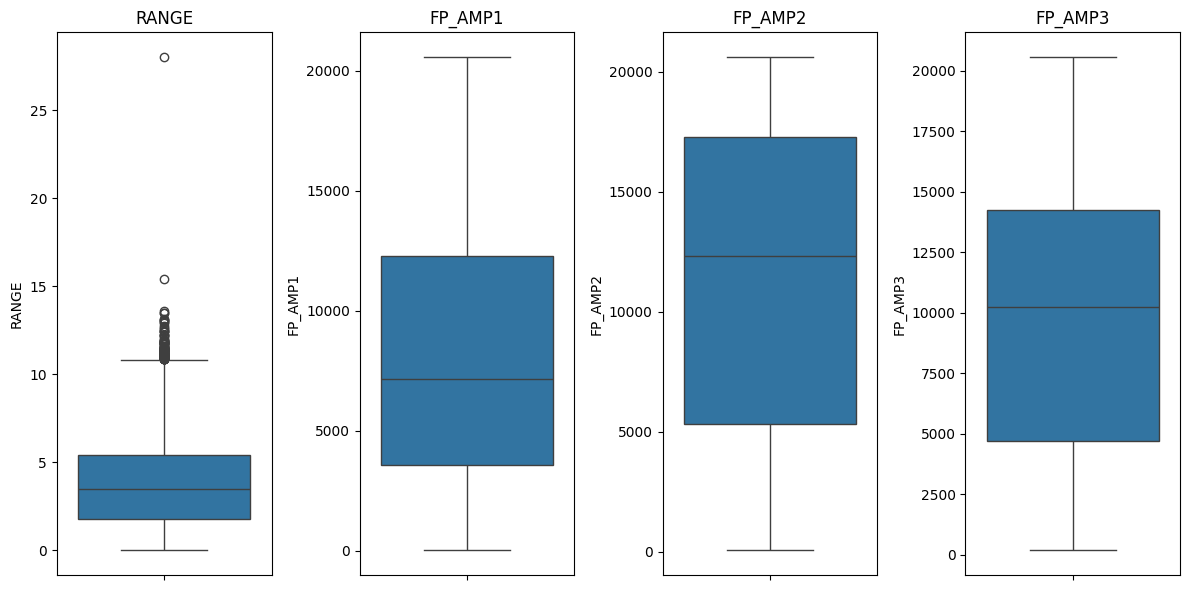

In [ ]:
# Features for outlier detection
features = ["RANGE", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Plot the boxplot
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()